In [1]:
!pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 497k/497k [00:00<00:00, 60.7MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind/versions/2
/root/.cache/kagglehub/datasets/anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind/versions/2/test.csv
/root/.cache/kagglehub/datasets/anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind/versions/2/train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

In [4]:
# Replace filename based on output above
file_path = os.path.join(path, "train.csv")

df = pd.read_csv(file_path)

df.head()

,bedroom,bathrooms,area,furnishing,avalable_for,address,floor_number,facing,floor_type,gate_community,...,pooja_room,study_room,others,servant_room,store_room,maintenance_amt,brok_amt,deposit_amt,mnt_amt,rent
0,2,2,1050.0,Unfurnished,All,"Sadguru hights, Pingale Wasti, , Pune, Maharas...",5,West,Marble,Yes,...,0,0,0,0,0,0,0,3,0.0,20000.0
1,2,2,760.0,Unfurnished,All,"Manav Silver Springs, Wagholi, , Pune, Maharas...",5,East,Vitrified,Yes,...,0,0,0,0,0,0,0,40000,0.0,14000.0
2,3,3,0.0,Semifurnished,All,"Saarrthi Souvenir, Mahalunge, , Pune, Maharashtra",1,South-West,Vitrified,Yes,...,0,0,1,0,0,Maintenance 1/ (/ month,23000,60000,1.0,22999.0
3,1,1,628.0,Furnished,Family Only,"Dhan Residency, Wanowrie, , Pune, Maharashtra",3,East,Mosaic,Yes,...,0,0,0,0,0,0,0,40000,0.0,13000.0
4,2,2,668.0,Semifurnished,"Family , Bachelors (Men Only)","Saptsiddhi Savali Homes, Uruli Devachi, , Pune...",6,South,Polished concrete,Yes,...,0,0,0,0,0,0,0,20,0.0,7500.0


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10884 entries, 0 to 10883
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bedroom            10884 non-null  int64  
 1   bathrooms          10884 non-null  int64  
 2   area               10884 non-null  float64
 3   furnishing         10884 non-null  object 
 4   avalable_for       10854 non-null  object 
 5   address            10884 non-null  object 
 6   floor_number       10884 non-null  int64  
 7   facing             10884 non-null  object 
 8   floor_type         10884 non-null  object 
 9   gate_community     10884 non-null  object 
 10  corner_pro         10884 non-null  object 
 11  parking            10884 non-null  int64  
 12  wheelchairadption  1944 non-null   object 
 13  petfacility        2426 non-null   object 
 14  aggDur             10884 non-null  int64  
 15  noticeDur          10884 non-null  int64  
 16  lightbill          108

,bedroom,bathrooms,area,floor_number,parking,aggDur,noticeDur,lightbill,powerbackup,no_room,pooja_room,study_room,others,servant_room,store_room,brok_amt,deposit_amt,mnt_amt,rent
count,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,10884.000000,1.088400e+04,10884.000000,1.088400e+04
mean,1.797868,1.779677,528.558560,3.062018,0.884693,7.423649,0.722345,0.172639,0.712422,0.750276,0.062201,0.048144,0.124495,0.032157,0.045296,7075.270764,3.670939e+04,257.493025,2.855947e+04
std,0.807328,0.832231,930.460935,2.390430,0.559457,7.670543,0.698966,0.377952,0.842667,0.432873,0.241532,0.214080,0.330160,0.176426,0.207962,17269.507644,5.589578e+04,1247.938097,1.183249e+06
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.600000e+03
25%,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+00,0.000000,1.050000e+04
50%,2.000000,2.000000,510.000000,3.000000,1.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000e+04,0.000000,1.500000e+04
75%,2.000000,2.000000,840.000000,5.000000,1.000000,11.000000,1.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9000.000000,5.000000e+04,0.000000,2.100000e+04
max,22.000000,22.000000,72775.000000,9.000000,9.000000,36.000000,6.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,275000.000000,1.500000e+06,40000.000000,1.234568e+08


In [6]:
df.isnull().sum()

,0
bedroom,0
bathrooms,0
area,0
furnishing,0
avalable_for,30
address,0
floor_number,0
facing,0
floor_type,0
gate_community,0


In [8]:
print(df.columns)

target_price_col = 'rent'  # change if needed

df['Target'] = (df[target_price_col] > df[target_price_col].median()).astype(int)

Index(['bedroom', 'bathrooms', 'area', 'furnishing', 'avalable_for', 'address',
       'floor_number', 'facing', 'floor_type', 'gate_community', 'corner_pro',
       'parking', 'wheelchairadption', 'petfacility', 'aggDur', 'noticeDur',
       'lightbill', 'powerbackup', 'propertyage', 'no_room', 'pooja_room',
       'study_room', 'others', 'servant_room', 'store_room', 'maintenance_amt',
       'brok_amt', 'deposit_amt', 'mnt_amt', 'rent'],
      dtype='object')


In [9]:
df_clean = df.select_dtypes(include=[np.number])

df_clean.head()

,bedroom,bathrooms,area,floor_number,parking,aggDur,noticeDur,lightbill,powerbackup,no_room,pooja_room,study_room,others,servant_room,store_room,brok_amt,deposit_amt,mnt_amt,rent,Target
0,2,2,1050.0,5,0,11,2,0,2,1,0,0,0,0,0,0,3,0.0,20000.0,1
1,2,2,760.0,5,2,11,1,0,2,1,0,0,0,0,0,0,40000,0.0,14000.0,0
2,3,3,0.0,1,1,11,1,0,2,0,0,0,1,0,0,23000,60000,1.0,22999.0,1
3,1,1,628.0,3,1,11,1,0,0,1,0,0,0,0,0,0,40000,0.0,13000.0,0
4,2,2,668.0,6,1,12,1,1,1,1,0,0,0,0,0,0,20,0.0,7500.0,0


In [10]:
df_clean = df_clean.fillna(0)

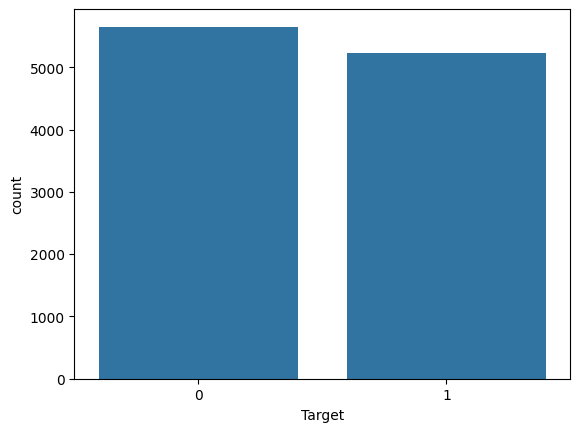

In [11]:
sns.countplot(x='Target', data=df_clean)
plt.show()

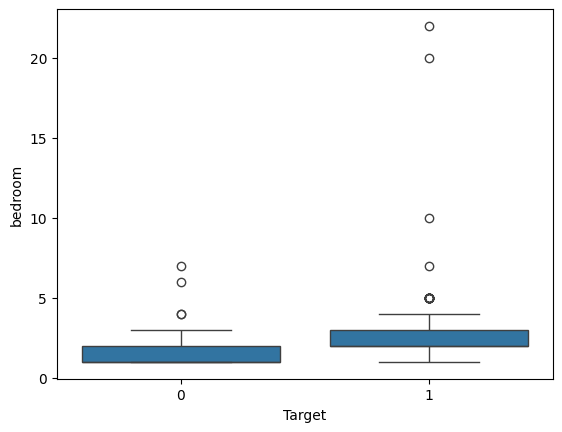

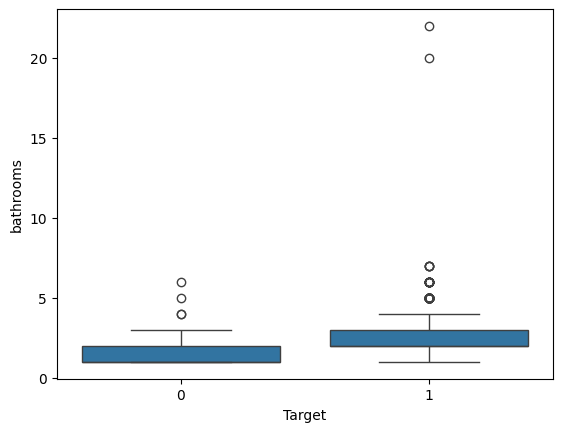

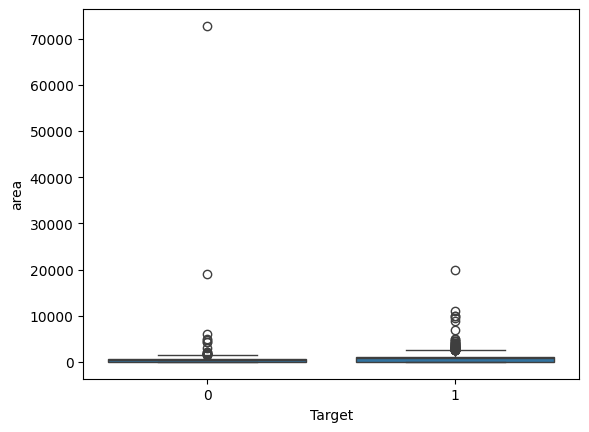

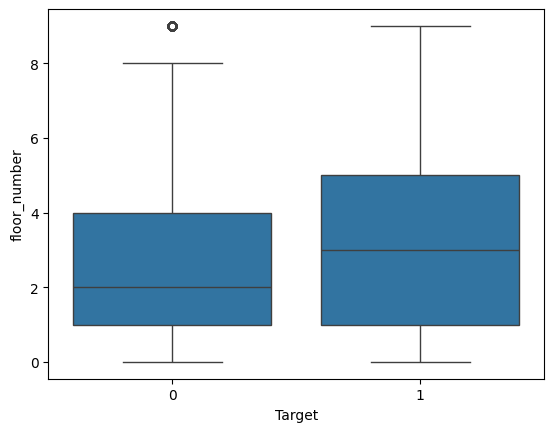

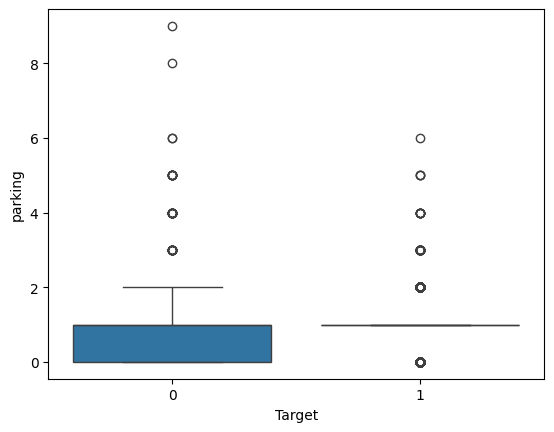

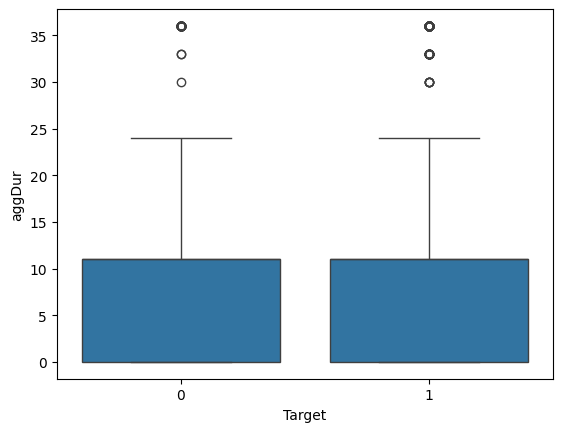

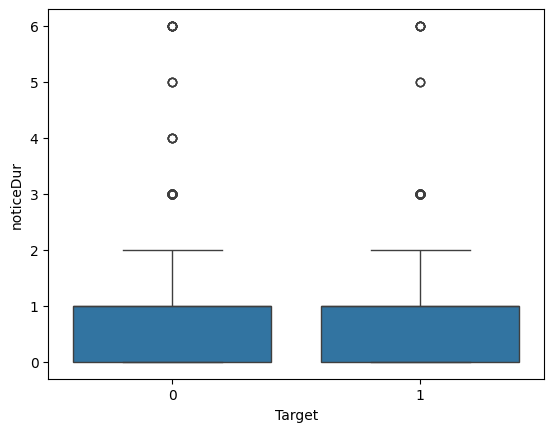

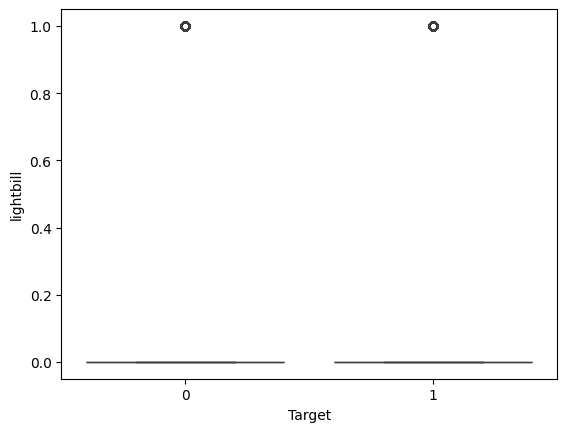

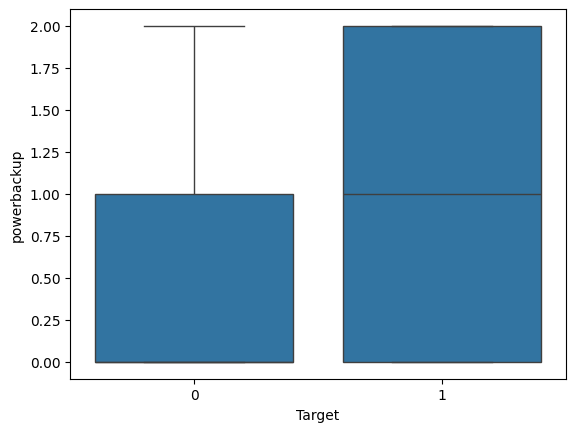

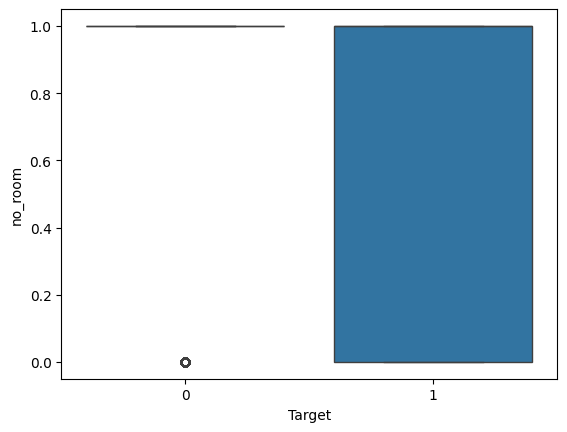

In [12]:
features = list(df_clean.columns[:10])

for col in features:
    if col != 'Target':
        sns.boxplot(x='Target', y=col, data=df_clean)
        plt.show()

In [13]:
X = df_clean.drop(['Target', target_price_col], axis=1)
y = df_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8750574184657786

Confusion Matrix:
 [[999 131]
 [141 906]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88      1130
           1       0.87      0.87      0.87      1047

    accuracy                           0.88      2177
   macro avg       0.87      0.87      0.87      2177
weighted avg       0.88      0.88      0.88      2177



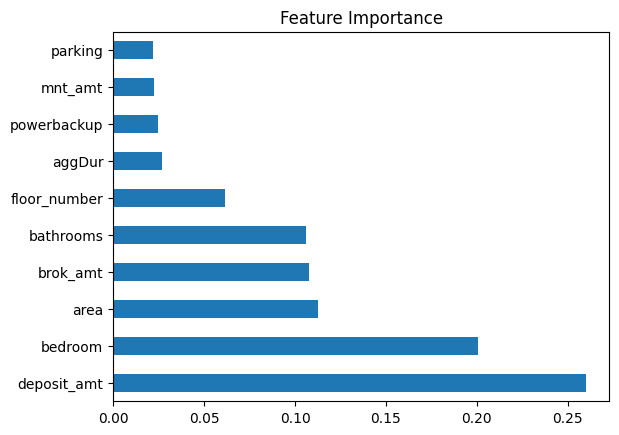

In [17]:
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [18]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    refit=True,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_dep

GridSearchCV(estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [19]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [20]:
grid_pred = grid.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, grid_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, grid_pred))

print("\nClassification Report:\n", classification_report(y_test, grid_pred))

Accuracy: 0.8750574184657786

Confusion Matrix:
 [[993 137]
 [135 912]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88      1130
           1       0.87      0.87      0.87      1047

    accuracy                           0.88      2177
   macro avg       0.87      0.87      0.87      2177
weighted avg       0.88      0.88      0.88      2177

